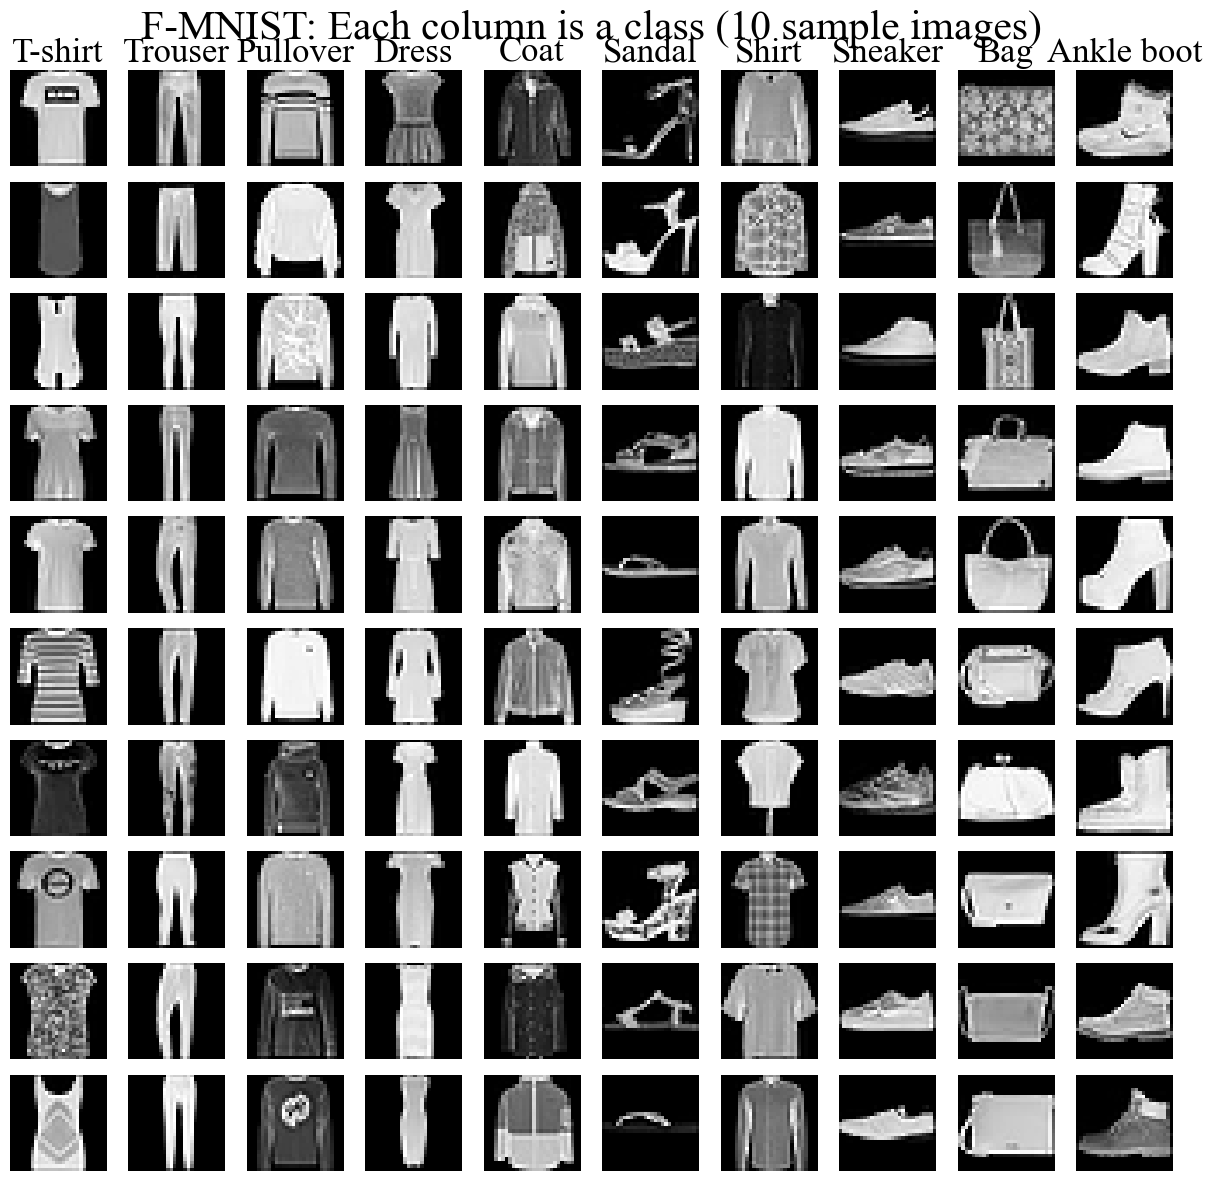

In [1]:
# Import libraries and utility functions
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

from matplotlib import rcParams

# Configure plot appearance settings
rcParams['font.family'] = 'serif'           # Use serif font family
rcParams['font.serif'] = ['Times New Roman'] # Set Times New Roman as the specific font

# 1. Load the Fashion-MNIST dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# 2. Normalize pixel values to the range [0, 1]

X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

# Add channel dimension to match (N, 28, 28, 1) expected by Keras
X_train = X_train[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

# 3. Class names for display purposes
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 4. Display a grid where each column is a class and shows 10 example images
num_examples = 10
fig, axes = plt.subplots(num_examples, 10, figsize=(12, 12))

for col, label in enumerate(range(10)):
    # Select the first 10 images that belong to the current label
    idxs = np.where(y_train == label)[0][:num_examples]

    for row in range(num_examples):
        ax = axes[row, col]
        ax.imshow(X_train[idxs[row]].squeeze(), cmap='gray')  # Show grayscale image
        ax.axis('off')  # Turn off axis ticks

        # Only show the class name at the top row
        if row == 0:
            ax.set_title(class_names[label], fontsize=25)

plt.suptitle("F-MNIST: Each column is a class (10 sample images)", fontsize=30)
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()


In [2]:
# Convert integer labels to one-hot encoding for training
y_train_onehot = to_categorical(y_train, num_classes=10)
y_test_onehot  = to_categorical(y_test, num_classes=10)

# Print a sample of the one-hot labels (for quick inspection)
print(y_train_onehot)
# print(y_test_onehot)

[[0. 0. 0. ... 0. 0. 1.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [3]:
from sklearn.model_selection import train_test_split

# Split the original training set into a smaller training subset and a validation set (20% for validation)
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train_onehot, test_size=0.2, random_state=42)

# Print shapes to verify the split
print(f"Train: {X_train_sub.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Train: (48000, 28, 28, 1), Val: (12000, 28, 28, 1), Test: (10000, 28, 28, 1)


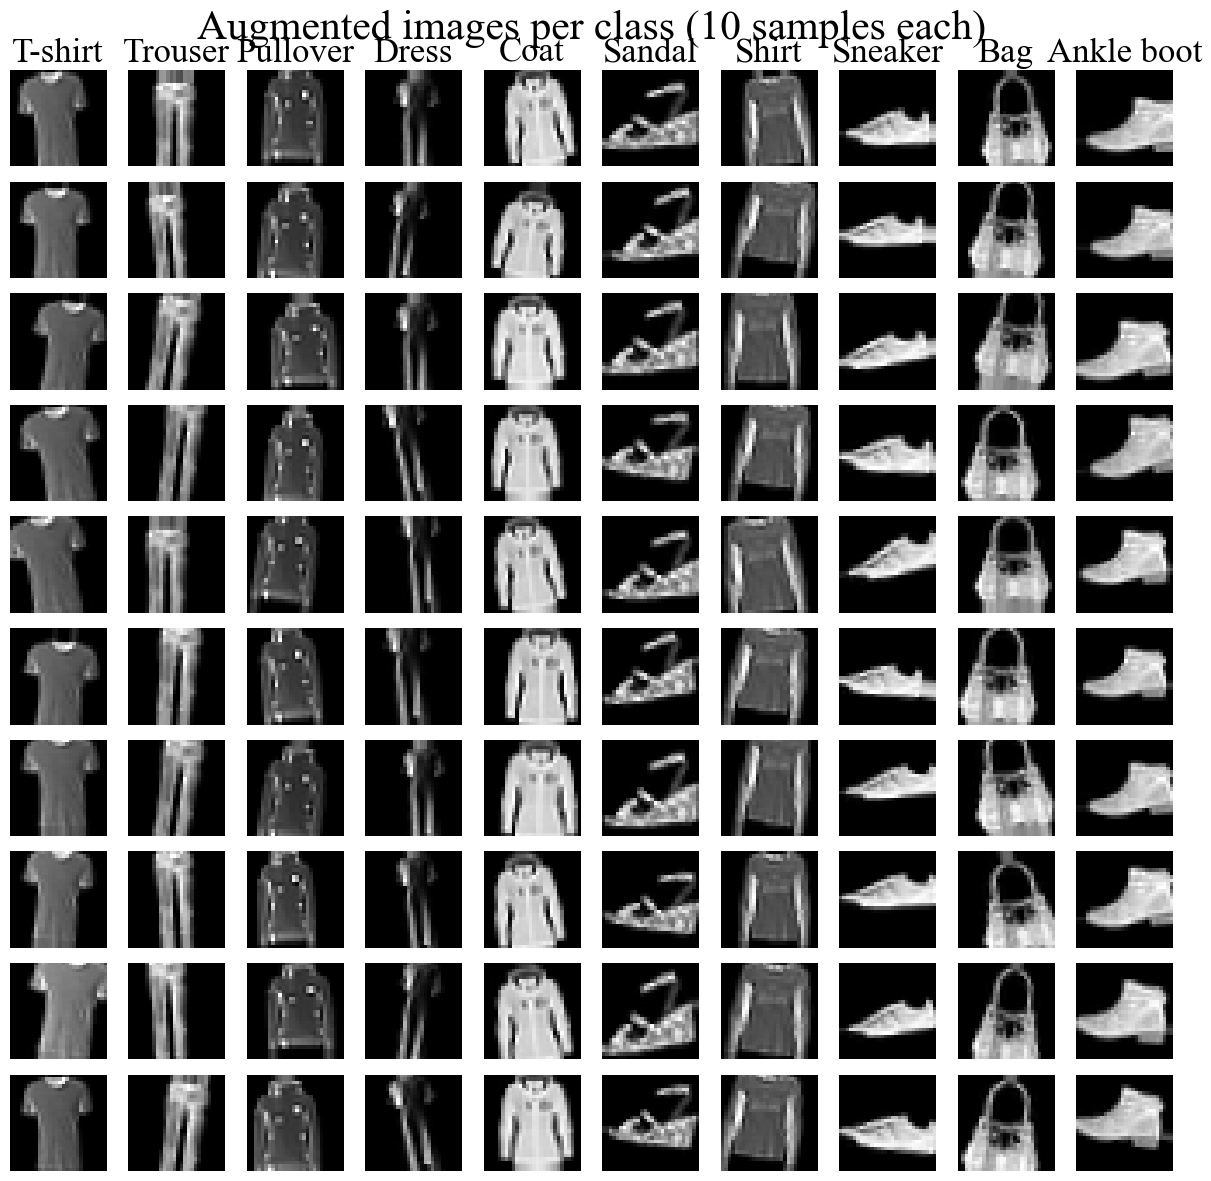

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create an image data generator for simple augmentation operations
datagen = ImageDataGenerator(
    rotation_range=10,         # Rotate images by ±10 degrees
    width_shift_range=0.1,     # Horizontal shift
    height_shift_range=0.1,    # Vertical shift
    zoom_range=0.1             # Small zoom in/out
)

# Ensure training subset has explicit channel dimension (N, 28, 28, 1)
if X_train_sub.ndim == 3:
    X_train_sub = X_train_sub[..., np.newaxis]

# Fit generator internal statistics if needed (not strictly required for these transforms)
datagen.fit(X_train_sub)

# Prepare a list to store augmented images for each label
augmented_images = []

for label in range(10):
    # Find index of the first example for this label in the training subset
    idx = np.where(np.argmax(y_train_sub, axis=1) == label)[0][0]
    image = X_train_sub[idx]  # shape: (28, 28, 1)
    image = np.expand_dims(image, axis=0)  # shape: (1, 28, 28, 1) for the generator

    # Initialize a generator that yields augmented images from the single example
    gen = datagen.flow(image, batch_size=1)

    # Generate 10 distinct augmented images for this label
    label_images = [next(gen)[0] for _ in range(10)]

    # Append list of augmented images for this label
    augmented_images.append(label_images)

# Display the augmented images in a 10x10 grid: columns are labels, rows are augmentations
fig, axes = plt.subplots(10, 10, figsize=(12, 12))

for col in range(10):  # Iterate over labels
    for row in range(10):  # Iterate over augmented samples per label
        ax = axes[row, col]
        ax.imshow(augmented_images[col][row].squeeze(), cmap='gray')
        ax.axis('off')
        if row == 0:
            ax.set_title(class_names[col], fontsize=25)

plt.suptitle("Augmented images per class (10 samples each)", fontsize=30)
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

In [5]:
# Compute and print the total number of augmented images generated
total_augmented = sum(len(images) for images in augmented_images)
print(f"Total augmented images generated: {total_augmented}")


Total augmented images generated: 100
